# One-Dimensional Interpolation

One-dimensional interpolation estimates unknown function values between discrete data points by constructing a continuous approximation from the available samples. In computational physics, interpolation is widely used to reconstruct experimental measurements, evaluate numerical solutions at intermediate locations, and prepare data for visualization and post-processing. This notebook compares linear, quadratic, and cubic interpolation using a damped oscillatory signal.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [12]:
np.random.seed(42)
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Sample Data

The reference signal is defined as a damped harmonic oscillation,

$$x(t)=Ae^{-\gamma t}\cos(\omega t)$$

where $A$ is the initial amplitude, $\gamma$ is the damping coefficient, and $\omega$ is the angular frequency. This analytical function serves as the reference solution for evaluating the interpolation methods.

In [ ]:
A = 1
gamma = 0.2
omega = 1

In [14]:
t_true = np.linspace(0, 8*np.pi, 1000)
x_true = A * np.exp(-gamma * t_true) * np.cos(omega * t_true)

A finite number of sample points is extracted from the reference function and small random perturbations are added to simulate measurement noise.

In [ ]:
t_data = np.linspace(0, 8*np.pi, 17)
x_data = A * np.exp(-gamma * t_data) * np.cos(omega * t_data)
x_data_noisy = x_data + np.random.normal(0, 0.01, len(t_data))

The scatter plot compares the noisy measurements with the underlying analytical function before interpolation is performed.

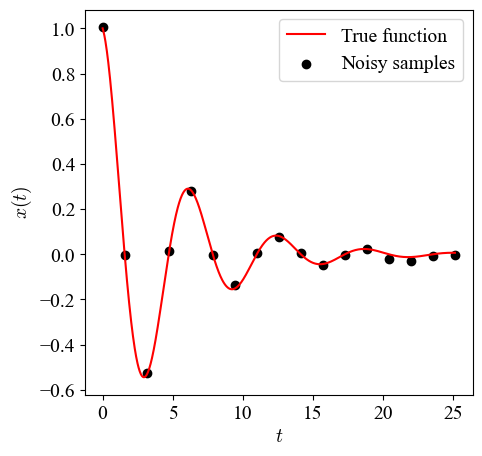

In [16]:
plt.figure(figsize=(5, 5))
plt.plot(t_true, x_true, color="r", label="True function")
plt.scatter(t_data, x_data_noisy, color="k", label="Noisy samples")
plt.legend()
plt.xlabel(r"$t$")
plt.ylabel(r"$x(t)$")
plt.show()

## Interpolation Methods

Interpolation constructs a continuous function that passes through the available data points. Unlike regression, which determines the best-fit approximation, interpolation exactly reproduces the sampled values within the interpolation interval. Several interpolation methods are commonly used, differing in the polynomial degree and resulting smoothness.

Linear interpolation connects two neighboring data points with a straight line,

$$
y(x)=y_0+\frac{y_1-y_0}{x_1-x_0}(x-x_0).
$$

Quadratic interpolation approximates the data using a second-degree polynomial,

$$
y(x)=a_2x^2+a_1x+a_0,
$$

whose coefficients are obtained by solving

$$
\begin{bmatrix}
x_0^2 & x_0 & 1\\
x_1^2 & x_1 & 1\\
x_2^2 & x_2 & 1\
\end{bmatrix}
\begin{bmatrix}
a_2\\
a_1\\
a_0
\end{bmatrix}
=
\begin{bmatrix}
y_0\\
y_1\\
y_2
\end{bmatrix}.
$$

Similarly, cubic interpolation employs a third-degree polynomial,

$$
y(x)=a_3x^3+a_2x^2+a_1x+a_0,
$$

with coefficients satisfying

$$
\begin{bmatrix}
x_0^3 & x_0^2 & x_0 & 1\\
x_1^3 & x_1^2 & x_1 & 1\\
x_2^3 & x_2^2 & x_2 & 1\\
x_3^3 & x_3^2 & x_3 & 1
\end{bmatrix}
\begin{bmatrix}
a_3\\
a_2\\
a_1\\
a_0
\end{bmatrix}
=
\begin{bmatrix}
y_0\\
y_1\\
y_2\\
y_3
\end{bmatrix}.
$$

These linear systems may be solved using standard techniques such as Gaussian elimination, LU decomposition, or Cramer's rule for small systems. In practice, `scipy.interpolate.interp1d` automatically constructs the required piecewise polynomial interpolants, allowing the interpolation function to be evaluated efficiently over the desired interval.

In [17]:
f_linear = interpolate.interp1d(t_data, x_data_noisy, kind="linear")
f_quadratic = interpolate.interp1d(t_data, x_data_noisy, kind="quadratic")
f_cubic = interpolate.interp1d(t_data, x_data_noisy, kind="cubic")
x_linear = f_linear(t_true)
x_quadratic = f_quadratic(t_true)
x_cubic = f_cubic(t_true)

The interpolated curves are compared with the analytical solution and noisy measurements to illustrate the accuracy and smoothness of each interpolation method.

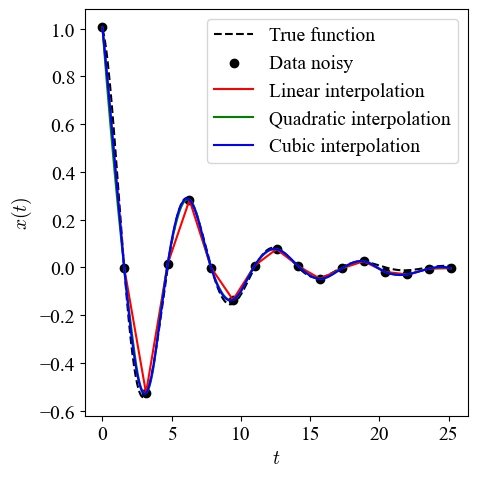

In [18]:
plt.figure(figsize=(5, 5))
plt.plot(t_true, x_true, "k--", label="True function")
plt.scatter(t_data, x_data_noisy, color="k", label="Data noisy")
plt.plot(t_true, x_linear, color="r", label="Linear interpolation")
plt.plot(t_true, x_quadratic, color="g", label="Quadratic interpolation")
plt.plot(t_true, x_cubic, color="b",  label="Cubic interpolation")
plt.legend()
plt.xlabel(r"$t$")
plt.ylabel(r"$x(t)$")
plt.tight_layout()
plt.show()

## Model Evaluation

The interpolation methods are evaluated using the mean absolute error (MAE),

$$
\mathrm{MAE}=\frac{1}{n}\sum_{i=1}^{n}\left|x_i-\hat{x}_i\right|,
$$

and the root mean squared error (RMSE),

$$
\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i-\hat{x}_i)^2},
$$

where $x_i$ denotes the analytical solution and $\hat{x}_i$ the interpolated value. These metrics quantify the interpolation accuracy relative to the reference function.

In [19]:
def eval(name, pred):
    mae = mean_absolute_error(x_true, pred)
    rmse = root_mean_squared_error(x_true, pred)
    print(f"{name}: MAE={mae:.5f}, RMSE={rmse:.5f}")

In [20]:
eval("Linear", x_linear)
eval("Quadratic", x_quadratic)
eval("Cubic", x_cubic)

Linear: MAE=0.02869, RMSE=0.04544
Quadratic: MAE=0.01629, RMSE=0.03100
Cubic: MAE=0.01204, RMSE=0.02042


## Key Insights

* One-dimensional interpolation reconstructs continuous functions from discrete sample points.
* Linear, quadratic, and cubic interpolation provide increasing levels of smoothness and approximation accuracy for sufficiently smooth data.
* The interpolation quality depends on both the sampling density and the characteristics of the underlying function.